<a href="https://colab.research.google.com/github/poojaashree2007/CODEVEDX_TASK_3/blob/main/CODEVEDX_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

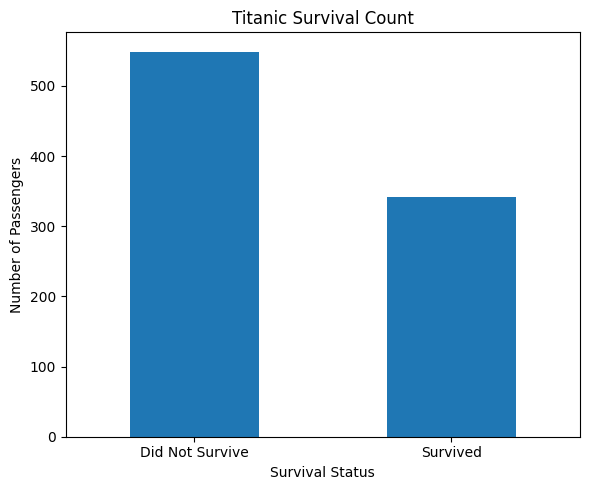

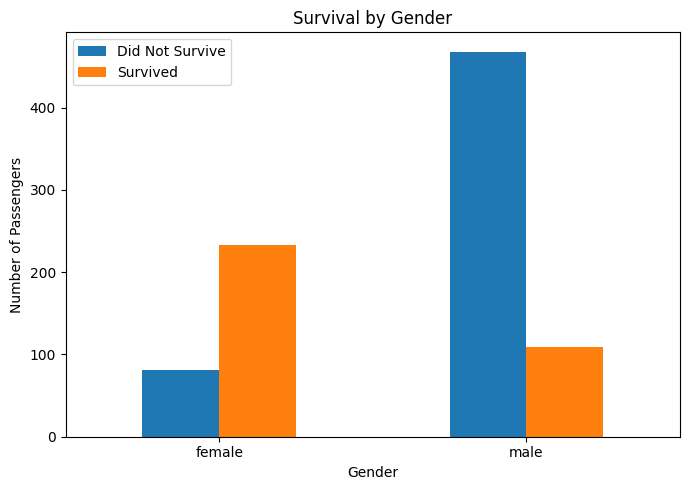

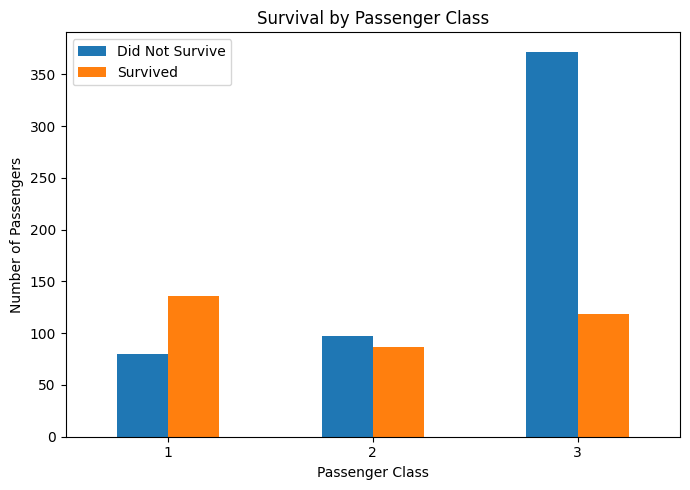

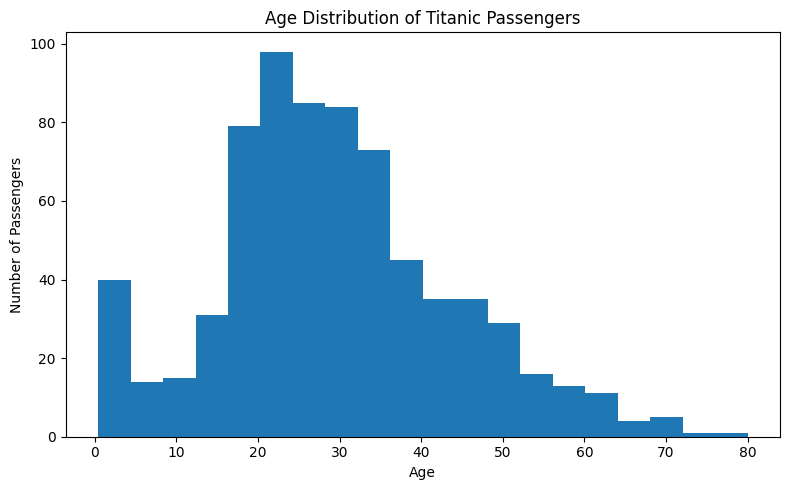

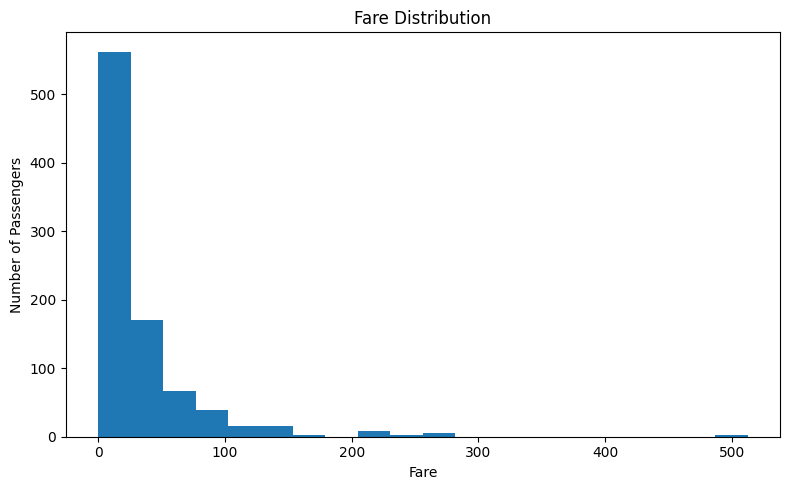

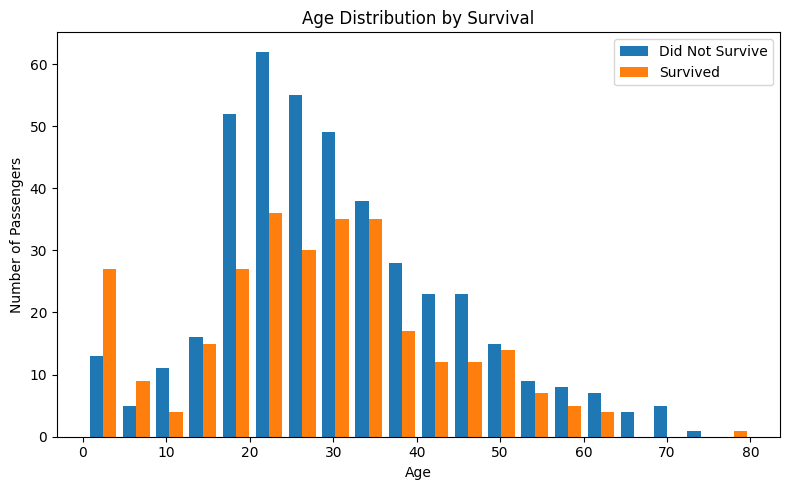


Model Accuracy:
80.45 %

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179


Confusion Matrix:
[[98 12]
 [23 46]]


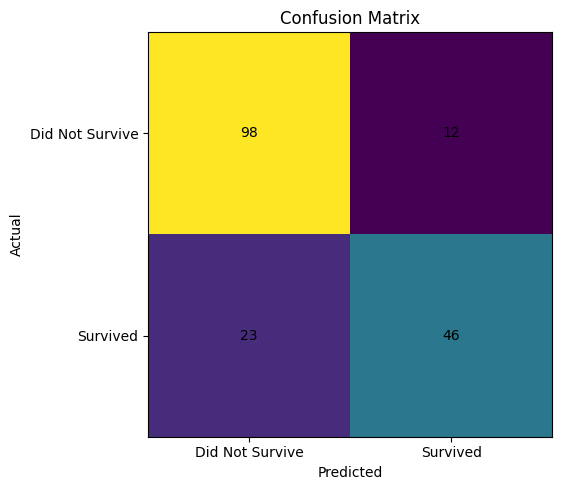


New Passenger Prediction:
Survived


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

data = pd.read_csv("Titanic-Dataset.csv")

data.columns = data.columns.str.strip()

print("First 5 Rows:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nMissing Values:")
print(data.isnull().sum())

plt.figure(figsize=(6, 5))
data["Survived"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.title("Titanic Survival Count")
plt.xticks([0, 1], ["Did Not Survive", "Survived"], rotation=0)
plt.tight_layout()
plt.show()

if "Sex" in data.columns:
    survival_gender = pd.crosstab(data["Sex"], data["Survived"])

    survival_gender.plot(
        kind="bar",
        figsize=(7, 5)
    )

    plt.xlabel("Gender")
    plt.ylabel("Number of Passengers")
    plt.title("Survival by Gender")
    plt.xticks(rotation=0)
    plt.legend(["Did Not Survive", "Survived"])
    plt.tight_layout()
    plt.show()

if "Pclass" in data.columns:
    survival_class = pd.crosstab(data["Pclass"], data["Survived"])

    survival_class.plot(
        kind="bar",
        figsize=(7, 5)
    )

    plt.xlabel("Passenger Class")
    plt.ylabel("Number of Passengers")
    plt.title("Survival by Passenger Class")
    plt.xticks(rotation=0)
    plt.legend(["Did Not Survive", "Survived"])
    plt.tight_layout()
    plt.show()

if "Age" in data.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(data["Age"].dropna(), bins=20)
    plt.xlabel("Age")
    plt.ylabel("Number of Passengers")
    plt.title("Age Distribution of Titanic Passengers")
    plt.tight_layout()
    plt.show()

if "Fare" in data.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(data["Fare"].dropna(), bins=20)
    plt.xlabel("Fare")
    plt.ylabel("Number of Passengers")
    plt.title("Fare Distribution")
    plt.tight_layout()
    plt.show()

if "Age" in data.columns and "Survived" in data.columns:
    survived_age = data[data["Survived"] == 1]["Age"].dropna()
    not_survived_age = data[data["Survived"] == 0]["Age"].dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(
        [not_survived_age, survived_age],
        bins=20,
        label=["Did Not Survive", "Survived"]
    )
    plt.xlabel("Age")
    plt.ylabel("Number of Passengers")
    plt.title("Age Distribution by Survival")
    plt.legend()
    plt.tight_layout()
    plt.show()

drop_columns = [
    "Survived",
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin"
]

X = data.drop(
    columns=[column for column in drop_columns if column in data.columns]
)

y = data["Survived"]

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_columns),
        ("categorical", categorical_pipeline, categorical_columns)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Did Not Survive", "Survived"]
    )
)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.yticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": ["female"],
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [20],
    "Embarked": ["S"]
})

new_prediction = model.predict(new_passenger)

print("\nNew Passenger Prediction:")

if new_prediction[0] == 1:
    print("Survived")
else:
    print("Did Not Survive")